In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import gc
import handy.my_utils as deniz
from EEGPreprocessor import EEGPreprocessor
import mne

In [6]:
data = np.load('processed_8_patients_2s/chb01_chb01_03.npz')
X = data['X']
y = data['y']

print(X.shape)
print(y.shape)

(218, 18, 256)
(218,)


In [7]:
CHB_MIT_PATH = 'data-understanding/data/chb-mit'
preprocessor = EEGPreprocessor(sampling_rate=256, target_sfreq=128)
new_fs = preprocessor.target_sfreq
all_annotations = {}
patient_dirs = sorted([d for d in os.listdir(CHB_MIT_PATH)
                       if os.path.isdir(os.path.join(CHB_MIT_PATH, d))
                       and d.startswith('chb')])

total_seizures = 0
total_files_with_seizures = 0

print(f"\n👥 Processing {len(patient_dirs)} patients...\n")

for patient in patient_dirs:
    patient_path = os.path.join(CHB_MIT_PATH, patient)
    summary_file = os.path.join(patient_path, f'{patient}-summary.txt')

    if os.path.exists(summary_file):
        seizure_info = deniz.parse_summary_file(summary_file)

        if seizure_info:
            all_annotations[patient] = seizure_info
            n_files = len(seizure_info)
            n_seizures = sum(len(times) for times in seizure_info.values())
            total_files_with_seizures += n_files
            total_seizures += n_seizures

            print(f"   ✓ {patient}: {n_files} files, {n_seizures} seizures")
        else:
            print(f"   - {patient}: No seizures found")
    else:
        print(f"   ✗ {patient}: No summary file")


👥 Processing 24 patients...

   ✓ chb01: 7 files, 7 seizures
   ✓ chb02: 3 files, 3 seizures
   ✓ chb03: 7 files, 7 seizures
   ✓ chb04: 3 files, 4 seizures
   ✓ chb05: 5 files, 5 seizures
   ✓ chb06: 7 files, 10 seizures
   ✓ chb07: 3 files, 3 seizures
   ✓ chb08: 5 files, 5 seizures
   ✓ chb09: 3 files, 4 seizures
   ✓ chb10: 7 files, 7 seizures
   ✓ chb11: 3 files, 3 seizures
   ✓ chb12: 13 files, 40 seizures
   ✓ chb13: 8 files, 12 seizures
   ✓ chb14: 7 files, 8 seizures
   ✓ chb15: 14 files, 20 seizures
   ✓ chb16: 6 files, 10 seizures
   ✓ chb17: 3 files, 3 seizures
   ✓ chb18: 6 files, 6 seizures
   ✓ chb19: 3 files, 3 seizures
   ✓ chb20: 6 files, 8 seizures
   ✓ chb21: 4 files, 4 seizures
   ✓ chb22: 3 files, 3 seizures
   ✓ chb23: 3 files, 7 seizures
   ✓ chb24: 12 files, 16 seizures


In [8]:
all_annotations

{'chb01': {'chb01_03.edf': [(2996, 3036)],
  'chb01_04.edf': [(1467, 1494)],
  'chb01_15.edf': [(1732, 1772)],
  'chb01_16.edf': [(1015, 1066)],
  'chb01_18.edf': [(1720, 1810)],
  'chb01_21.edf': [(327, 420)],
  'chb01_26.edf': [(1862, 1963)]},
 'chb02': {'chb02_16.edf': [(130, 212)],
  'chb02_16+.edf': [(2972, 3053)],
  'chb02_19.edf': [(3369, 3378)]},
 'chb03': {'chb03_01.edf': [(362, 414)],
  'chb03_02.edf': [(731, 796)],
  'chb03_03.edf': [(432, 501)],
  'chb03_04.edf': [(2162, 2214)],
  'chb03_34.edf': [(1982, 2029)],
  'chb03_35.edf': [(2592, 2656)],
  'chb03_36.edf': [(1725, 1778)]},
 'chb04': {'chb04_05.edf': [(7804, 7853)],
  'chb04_08.edf': [(6446, 6557)],
  'chb04_28.edf': [(1679, 1781), (3782, 3898)]},
 'chb05': {'chb05_06.edf': [(417, 532)],
  'chb05_13.edf': [(1086, 1196)],
  'chb05_16.edf': [(2317, 2413)],
  'chb05_17.edf': [(2451, 2571)],
  'chb05_22.edf': [(2348, 2465)]},
 'chb06': {'chb06_01.edf': [(1724, 1738), (7461, 7476), (13525, 13540)],
  'chb06_04.edf': [(327,

In [11]:
import pandas as pd

# Boş listeler oluşturalım
patients = []
files = []
seizure_starts = []
seizure_ends = []

# İç içe geçmiş yapıyı düzleştirelim
for patient, patient_data in all_annotations.items():
    for file_name, seizures in patient_data.items():
        for seizure in seizures:
            start, end = seizure
            patients.append(patient)
            files.append(file_name)
            seizure_starts.append(start)
            seizure_ends.append(end)

# DataFrame oluşturalım
df_seizures = pd.DataFrame({
    'patient': patients,
    'file': files,
    'seizure_start': seizure_starts,
    'seizure_end': seizure_ends
})

# Ek olarak seizure_duration sütunu ekleyelim (opsiyonel)
df_seizures['seizure_duration'] = df_seizures['seizure_end'] - df_seizures['seizure_start']

# DataFrame'i görüntüleyelim
print(df_seizures.head())
print(f"\nTotal seizure count: {len(df_seizures)}")
print(f"Total patient count: {df_seizures['patient'].nunique()}")

df_seizures.to_csv('all_annotations.csv', index=False, encoding='utf-8-sig')

  patient          file  seizure_start  seizure_end  seizure_duration
0   chb01  chb01_03.edf           2996         3036                40
1   chb01  chb01_04.edf           1467         1494                27
2   chb01  chb01_15.edf           1732         1772                40
3   chb01  chb01_16.edf           1015         1066                51
4   chb01  chb01_18.edf           1720         1810                90

Total seizure count: 185
Total patient count: 24


In [12]:
# drop exclude_list from all_annotations due to channels are too complicated.

exclude_list = [
    'chb12/chb12_29.edf',
    'chb12/chb12_27.edf',
    'chb12/chb12_28.edf'
]

# Sözlüğü güvenli bir şekilde güncellemek için iç içe döngü kullanıyoruz
for item in exclude_list:
    # item örneği: 'chb12/chb12_29.edf'
    # folder: 'chb12', filename: 'chb12_29.edf'
    folder, filename = item.split('/')

    # Eğer bu klasör ana sözlükte varsa ve dosya o klasörün içindeyse sil
    if folder in all_annotations and filename in all_annotations[folder]:
        del all_annotations[folder][filename]

# Sonucu doğrulamak için chb12 klasörüne bakalım
print(all_annotations['chb12'].keys())

dict_keys(['chb12_06.edf', 'chb12_08.edf', 'chb12_09.edf', 'chb12_10.edf', 'chb12_11.edf', 'chb12_23.edf', 'chb12_33.edf', 'chb12_36.edf', 'chb12_38.edf', 'chb12_42.edf'])


In [13]:
PATIENTS_TO_USE = ['chb01', 'chb03', 'chb06', 'chb10', 'chb14', 'chb15', 'chb16', 'chb24']

for patient_id in PATIENTS_TO_USE:
    file_names = all_annotations[patient_id].keys() # bu şekilde hastanın icindeki edf dosyalarını çekebiliyoruz mesela file_names ilk elemanı chb_01_03.edf
    print(file_names)

dict_keys(['chb01_03.edf', 'chb01_04.edf', 'chb01_15.edf', 'chb01_16.edf', 'chb01_18.edf', 'chb01_21.edf', 'chb01_26.edf'])
dict_keys(['chb03_01.edf', 'chb03_02.edf', 'chb03_03.edf', 'chb03_04.edf', 'chb03_34.edf', 'chb03_35.edf', 'chb03_36.edf'])
dict_keys(['chb06_01.edf', 'chb06_04.edf', 'chb06_09.edf', 'chb06_10.edf', 'chb06_13.edf', 'chb06_18.edf', 'chb06_24.edf'])
dict_keys(['chb10_12.edf', 'chb10_20.edf', 'chb10_27.edf', 'chb10_30.edf', 'chb10_31.edf', 'chb10_38.edf', 'chb10_89.edf'])
dict_keys(['chb14_03.edf', 'chb14_04.edf', 'chb14_06.edf', 'chb14_11.edf', 'chb14_17.edf', 'chb14_18.edf', 'chb14_27.edf'])
dict_keys(['chb15_06.edf', 'chb15_10.edf', 'chb15_15.edf', 'chb15_17.edf', 'chb15_20.edf', 'chb15_22.edf', 'chb15_28.edf', 'chb15_31.edf', 'chb15_40.edf', 'chb15_46.edf', 'chb15_49.edf', 'chb15_52.edf', 'chb15_54.edf', 'chb15_62.edf'])
dict_keys(['chb16_10.edf', 'chb16_11.edf', 'chb16_14.edf', 'chb16_16.edf', 'chb16_17.edf', 'chb16_18.edf'])
dict_keys(['chb24_01.edf', 'chb24_03

In [14]:
CHB_MIT_PATH = 'data-understanding/data/chb-mit'
FINAL_CHANNELS = [
    'FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1',
    'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1',
    'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2',
    'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2',
    'FZ-CZ', 'CZ-PZ'
]

# for patient_id in PATIENTS_TO_USE:
#     file_names = all_annotations[patient_id].keys() # bu şekilde hastanın icindeki edf dosyalarını çekebiliyoruz mesela file_names ilk elemanı chb_01_03.edf



signals, channel_names, fs = deniz.load_edf_file('data-understanding/data/chb-mit/chb01/chb01_03.edf')
signals2, channel_names2, fs2 = deniz.fix_eeg_channels_load_edf('data-understanding/data/chb-mit/chb01/chb01_03.edf',FINAL_CHANNELS,deniz.load_edf_file)

In [15]:
signals.shape

(23, 921600)

In [16]:
signals2.shape

(18, 921600)

### We create a raw file using signal, channel names, and fs. To do this, we need to create an info variable, which we do with the mne.create_info() function.

In [18]:
info = mne.create_info(ch_names=channel_names, sfreq=fs, ch_types='eeg')
info

<Info | 7 non-empty values
 bads: []
 ch_names: FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3, C3-P3, P3-O1, ...
 chs: 23 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: unspecified
 nchan: 23
 projs: []
 sfreq: 256.0 Hz
>

In [19]:
raw_created = mne.io.RawArray(signals, info)
print(raw_created.info)

<Info | 7 non-empty values
 bads: []
 ch_names: FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3, C3-P3, P3-O1, ...
 chs: 23 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: unspecified
 nchan: 23
 projs: []
 sfreq: 256.0 Hz
>


In [20]:
raw_created

<RawArray | 23 x 921600 (3600.0 s), ~161.7 MiB, data loaded>

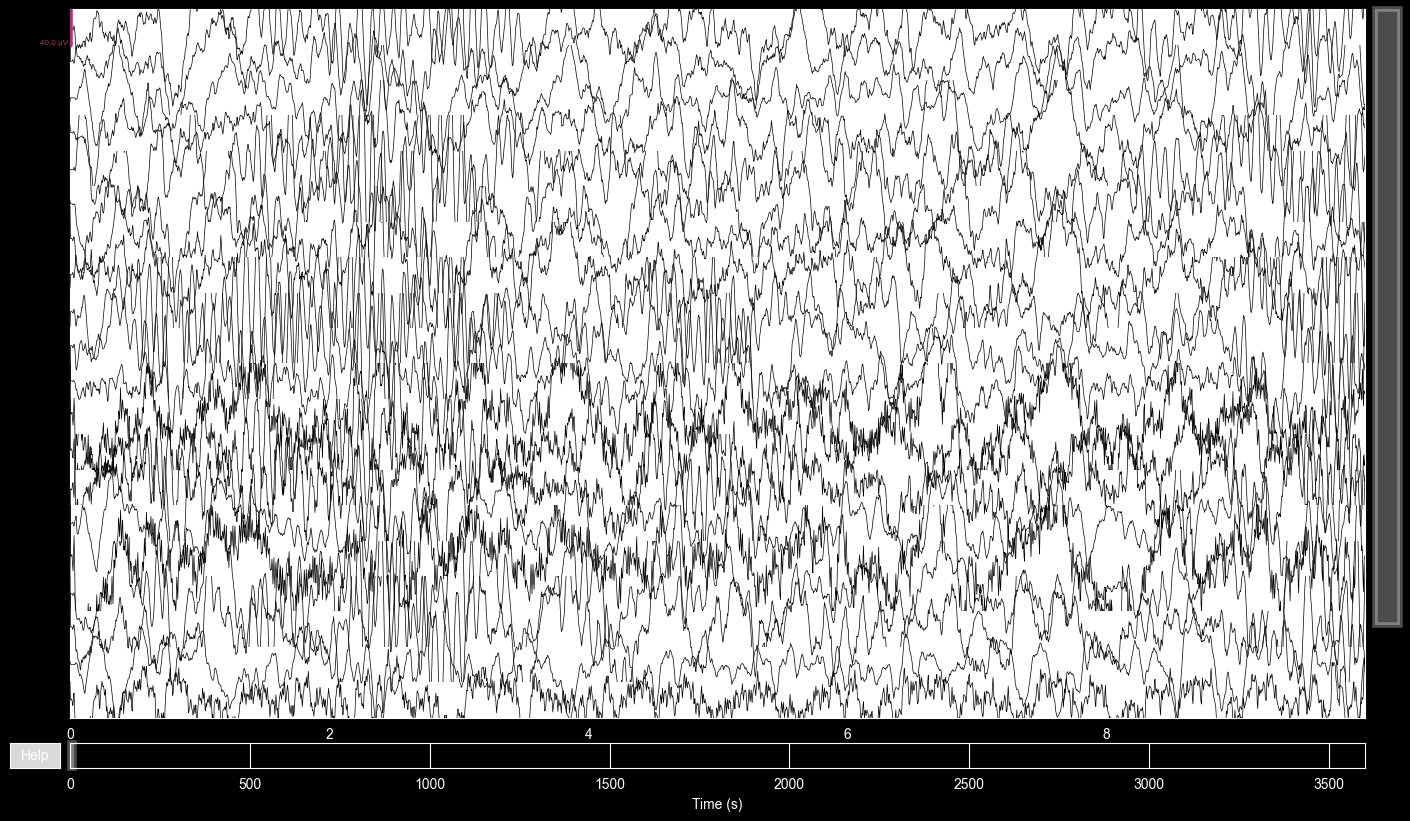

In [32]:
raw = mne.io.read_raw_edf('data-understanding/data/chb-mit/chb01/chb01_03.edf')
raw.plot(block=True)


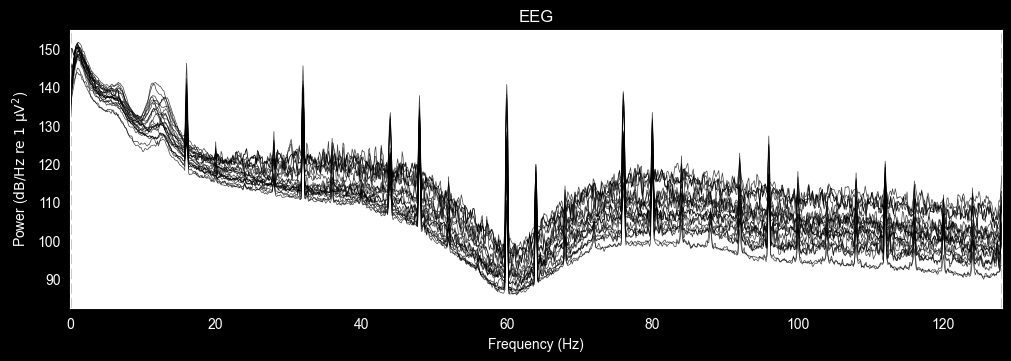

In [44]:
with plt.style.context({'axes.facecolor': 'white', 'axes.grid': False}):
    # Spatial colors help identify which area of the brain has more power
    raw_created.plot_psd(tmax=np.inf, average=False)

    plt.show()